# asses the history of runs


In [1]:
import sys
print(sys.executable)


import pandas as pd
%matplotlib inline

import matplotlib
print("backend:", matplotlib.get_backend())
import matplotlib.pyplot as plt

import corner
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


/home/kandrych/venvs/obriy311/bin/python
backend: module://matplotlib_inline.backend_inline


In [9]:



df_original=pd.read_csv("/fred/oz061/kandrych/smac/20260805_edge_no_puffed_narow2_budget14_teperedp1p2_pol_ssi_500_no_subl/smac_results/trials.csv")
results_dir="/fred/oz061/kandrych/smac/20260805_edge_no_puffed_narow2_budget14_teperedp1p2_pol_ssi_500_no_subl/smac_results/after_optimisation/"
Path(results_dir).mkdir(parents=True, exist_ok=True)

exclude = {"config_id", "seed", "budget", "cost", "time", "status", 
           'distance_pc', "zone_1_Rref", 'additional_info'}
#Because I did not yet figured out how to deal with additional info column, I will drop it for now. It is not needed for the optimisation anyway.
df = df_original.drop(columns=['additional_info'])

param_cols = [c for c in df.columns if c not in exclude]
print(param_cols)

df


['alpha_viscosity', 'inclination', 'zone_1_Rc', 'zone_1_Rin', 'zone_1_Rout', 'zone_1_dust_mass', 'zone_1_edge', 'zone_1_flaring_exp', 'zone_1_scale_height', 'zone_1_species_1_aexp', 'zone_1_species_1_amax', 'zone_1_species_1_amin', 'zone_1_species_1_porosity', 'zone_1_species_1_volume_fraction', 'zone_1_surface_density_exp']


,alpha_viscosity,distance_pc,inclination,zone_1_Rc,zone_1_Rin,zone_1_Rout,zone_1_Rref,zone_1_dust_mass,zone_1_edge,zone_1_flaring_exp,...,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.10000,1220.0,15.594601,199.670885,7.2,250,100,0.0020,0.1,0.803678,...,0.1,0.6,0.7,-0.004548,410,1562913011,14.1,4.096430e+02,372.932687,1
1,0.10000,1220.0,15.600071,199.087345,7.2,250,100,0.0020,0.1,0.803690,...,0.1,0.6,0.7,-0.004742,475,1562913011,14.1,4.147412e+02,376.490304,1
2,0.10000,1220.0,15.618472,199.284310,7.2,250,100,0.0020,0.1,0.803305,...,0.1,0.6,0.7,-0.004489,363,1562913011,14.1,4.159553e+02,382.863909,1
3,0.10000,1220.0,15.282237,199.960518,7.2,250,100,0.0020,0.1,0.803690,...,0.1,0.6,0.7,-0.004742,359,1562913011,14.1,4.180586e+02,410.164221,1
4,0.10000,1220.0,15.068805,194.805986,7.2,250,100,0.0020,0.1,0.803550,...,0.1,0.6,0.7,-0.000205,424,1562913011,14.1,4.192082e+02,400.448201,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.00001,1220.0,32.085905,140.898752,7.2,250,100,0.0010,0.1,1.822205,...,0.1,0.6,0.7,-0.565423,137,1562913011,14.1,4.256677e+06,809.548515,1
496,0.00001,1220.0,33.620406,185.093614,7.2,250,100,0.0005,0.1,1.513140,...,0.1,0.6,0.7,-0.486831,102,1562913011,14.1,4.634560e+06,0.000000,1
497,0.00001,1220.0,33.132815,132.003756,7.2,250,100,0.0005,0.1,1.671398,...,0.1,0.6,0.7,-0.474953,129,1562913011,14.1,4.754501e+06,1401.816177,1
498,0.00001,1220.0,32.372865,170.923794,7.2,250,100,0.0010,0.1,1.758206,...,0.1,0.6,0.7,-0.053020,211,1562913011,14.1,4.838713e+06,547.701296,1


### Best configs table (at max budget)

In [10]:
top = df[df["budget"] == df["budget"].max()].nsmallest(20, "cost")
print("Top 20 max budget trials:")
top
#top.to_csv(results_dir / "top5_maxbudget.csv", index=False)



Top 20 max budget trials:


,alpha_viscosity,distance_pc,inclination,zone_1_Rc,zone_1_Rin,zone_1_Rout,zone_1_Rref,zone_1_dust_mass,zone_1_edge,zone_1_flaring_exp,...,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.1,1220.0,15.594601,199.670885,7.2,250,100,0.002,0.1,0.803678,...,0.1,0.6,0.7,-0.004548,410,1562913011,14.1,409.642961,372.932687,1
1,0.1,1220.0,15.600071,199.087345,7.2,250,100,0.002,0.1,0.803690,...,0.1,0.6,0.7,-0.004742,475,1562913011,14.1,414.741188,376.490304,1
2,0.1,1220.0,15.618472,199.284310,7.2,250,100,0.002,0.1,0.803305,...,0.1,0.6,0.7,-0.004489,363,1562913011,14.1,415.955259,382.863909,1
3,0.1,1220.0,15.282237,199.960518,7.2,250,100,0.002,0.1,0.803690,...,0.1,0.6,0.7,-0.004742,359,1562913011,14.1,418.058563,410.164221,1
4,0.1,1220.0,15.068805,194.805986,7.2,250,100,0.002,0.1,0.803550,...,0.1,0.6,0.7,-0.000205,424,1562913011,14.1,419.208179,400.448201,1
5,0.1,1220.0,15.607682,199.659005,7.2,250,100,0.002,0.1,0.803675,...,0.1,0.6,0.7,-0.008704,464,1562913011,14.1,426.434050,348.239862,1
6,0.1,1220.0,15.618472,199.716907,7.2,250,100,0.002,0.1,0.803305,...,0.1,0.6,0.7,-0.004489,441,1562913011,14.1,426.652126,359.269309,1
7,0.1,1220.0,15.594601,199.696476,7.2,250,100,0.002,0.1,0.803678,...,0.1,0.6,0.7,-0.004548,489,1562913011,14.1,429.995033,367.533783,1
8,0.1,1220.0,15.504495,196.975629,7.2,250,100,0.002,0.1,0.803413,...,0.1,0.6,0.7,-0.009831,353,1562913011,14.1,430.904882,363.064976,1
9,0.1,1220.0,15.567124,198.559615,7.2,250,100,0.002,0.1,0.802718,...,0.1,0.6,0.7,-0.008087,355,1562913011,14.1,431.251980,331.658287,1


### Crashed runs inspection

In [11]:
df["status"] = np.where((df["cost"]==1e99) | (df["cost"]==df["cost"].max()), "Crashed", "Success")
df.loc[df['cost'] == df['cost'].max(), 'cost'] = 1e99


crashed_trials=df[df["status"]=="Crashed"]
successful_trials=df[df["status"]=="Success"]

crash_rate = len(crashed_trials) / len(df)
print('Rate of crashed trials to all trials:', crash_rate)

crashed_trials.describe().T.join(
   successful_trials.describe().T,
   lsuffix="_crashed",
   rsuffix="_successful"
)





Rate of crashed trials to all trials: 0.002


,count_crashed,mean_crashed,std_crashed,min_crashed,25%_crashed,50%_crashed,75%_crashed,max_crashed,count_successful,mean_successful,std_successful,min_successful,25%_successful,50%_successful,75%_successful,max_successful
alpha_viscosity,1.0,1.000000e-05,NaN,1.000000e-05,1.000000e-05,1.000000e-05,1.000000e-05,1.000000e-05,499.0,5.196020e-02,4.975635e-02,1.000000e-05,1.000000e-03,1.000000e-01,1.000000e-01,1.000000e-01
distance_pc,1.0,1.220000e+03,NaN,1.220000e+03,1.220000e+03,1.220000e+03,1.220000e+03,1.220000e+03,499.0,1.220000e+03,0.000000e+00,1.220000e+03,1.220000e+03,1.220000e+03,1.220000e+03,1.220000e+03
inclination,1.0,2.663411e+01,NaN,2.663411e+01,2.663411e+01,2.663411e+01,2.663411e+01,2.663411e+01,499.0,2.302107e+01,7.849241e+00,1.502912e+01,1.566805e+01,2.025044e+01,2.955308e+01,3.994092e+01
zone_1_Rc,1.0,1.466504e+02,NaN,1.466504e+02,1.466504e+02,1.466504e+02,1.466504e+02,1.466504e+02,499.0,1.438152e+02,5.704597e+01,2.024694e+01,9.688053e+01,1.664531e+02,1.964666e+02,1.999930e+02
zone_1_Rin,1.0,7.200000e+00,NaN,7.200000e+00,7.200000e+00,7.200000e+00,7.200000e+00,7.200000e+00,499.0,7.200000e+00,6.045674e-14,7.200000e+00,7.200000e+00,7.200000e+00,7.200000e+00,7.200000e+00
zone_1_Rout,1.0,2.500000e+02,NaN,2.500000e+02,2.500000e+02,2.500000e+02,2.500000e+02,2.500000e+02,499.0,2.500000e+02,0.000000e+00,2.500000e+02,2.500000e+02,2.500000e+02,2.500000e+02,2.500000e+02
zone_1_Rref,1.0,1.000000e+02,NaN,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,499.0,1.000000e+02,0.000000e+00,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02
zone_1_dust_mass,1.0,1.000000e-04,NaN,1.000000e-04,1.000000e-04,1.000000e-04,1.000000e-04,1.000000e-04,499.0,2.684770e-03,2.819569e-03,1.000000e-04,1.000000e-03,2.000000e-03,4.000000e-03,1.000000e-02
zone_1_edge,1.0,1.000000e-01,NaN,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,499.0,1.000000e-01,8.751780e-16,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01
zone_1_flaring_exp,1.0,1.971006e+00,NaN,1.971006e+00,1.971006e+00,1.971006e+00,1.971006e+00,1.971006e+00,499.0,1.138975e+00,3.958247e-01,8.005262e-01,8.045443e-01,8.991481e-01,1.454433e+00,1.998237e+00


In [12]:
from pandas.api.types import is_numeric_dtype

def plot_crash_success_histograms(df, crashed, success, param_cols, results_dir=None, max_unique=20, nbins=30):

    crash_rate = len(crashed) / len(df)
    fig, axes = plt.subplots(
        len(param_cols), 1,
        figsize=(6, 3 * len(param_cols))
    )

    if len(param_cols) == 1:
        axes = [axes]

    
    for ax, p in zip(axes, param_cols):

        if is_numeric_dtype(df[p]):

            x_all = df[p].dropna()
            x_crash = crashed[p].dropna()
            x_success = success[p].dropna()

            unique = np.sort(x_all.unique())

            if len(unique) <= 20:
                crash_counts = x_crash.value_counts().reindex(unique, fill_value=0)
                success_counts = x_success.value_counts().reindex(unique, fill_value=0)

                xpos = np.arange(len(unique))
                width = 0.4

                ax.bar(xpos-width/2, crash_counts, width, label="Crash")
                ax.bar(xpos+width/2, success_counts, width, alpha=0.6, label="Success")

                ax.set_xticks(xpos)
                ax.set_xticklabels(unique, rotation=45)

            else:
                ax.hist(x_crash, bins=30, alpha=1, label="Crash")
                ax.hist(x_success, bins=30, alpha=0.6, label="Success")

        else:
            # Categorical parameter
            categories = df[p].dropna().unique()

            crash_counts = (
                crashed[p]
                .value_counts()
                .reindex(categories, fill_value=0)
            )

            success_counts = (
                success[p]
                .value_counts()
                .reindex(categories, fill_value=0)
            )

            xpos = np.arange(len(categories))
            width = 0.4

            ax.bar(xpos-width/2, crash_counts, width, label="Crash")
            ax.bar(xpos+width/2, success_counts, width, alpha=0.6, label="Success")

            ax.set_xticks(xpos)
            ax.set_xticklabels(categories, rotation=45)

        ax.set_xlabel(p)
        ax.legend()

    plt.tight_layout()

    plt.suptitle('Rate of crashed trials to all trials: {:.2f}'.format(crash_rate), fontsize=12, y=1.01)

    if results_dir is not None:
        plt.savefig(results_dir + "Histograms_crashed_vs_successful.png", dpi=150, bbox_inches="tight")

    plt.show()
    plt.close()

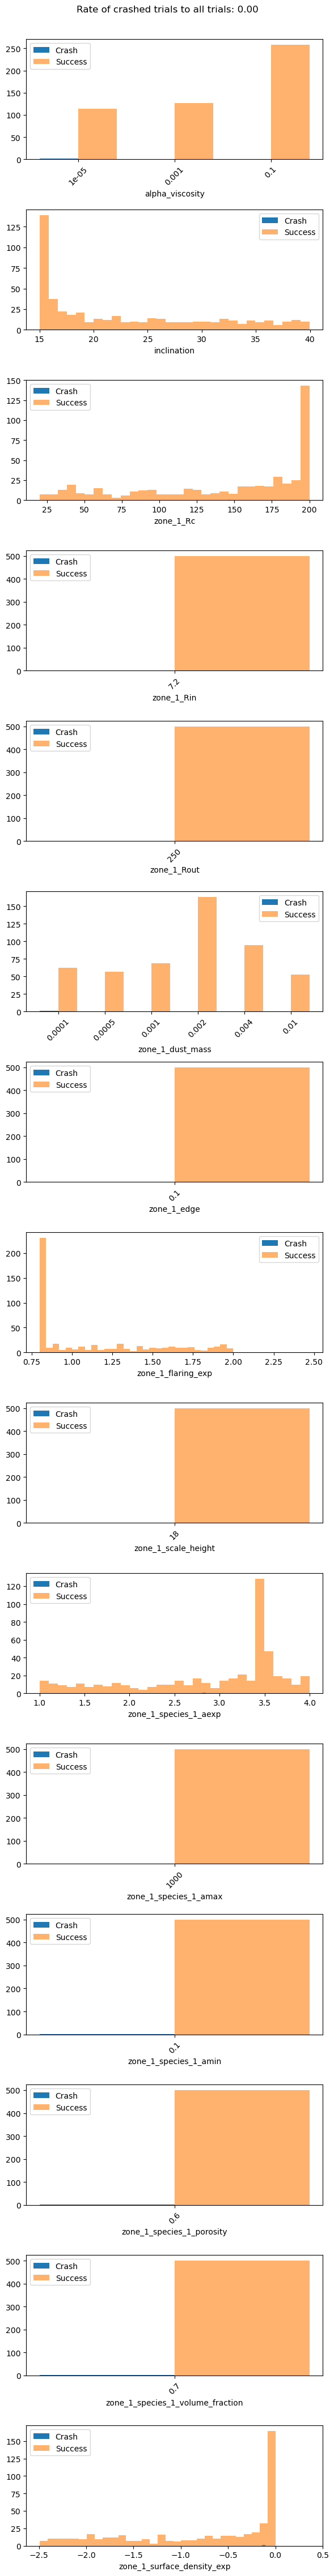

In [13]:
plot_crash_success_histograms(df, crashed_trials, successful_trials, param_cols, results_dir=results_dir, max_unique=20, nbins=30)

### Pairwise sanity checks (parameter vs cost)


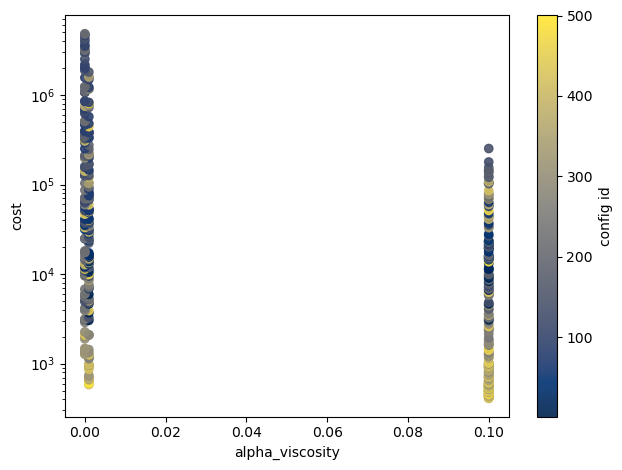

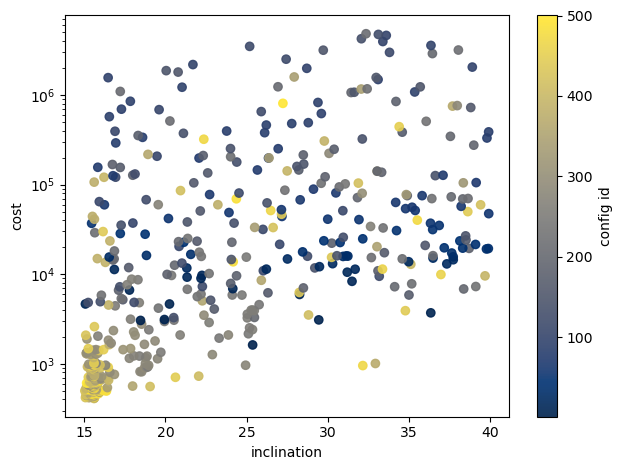

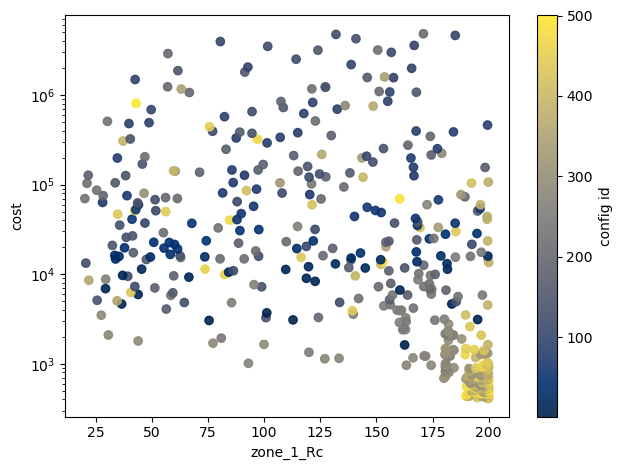

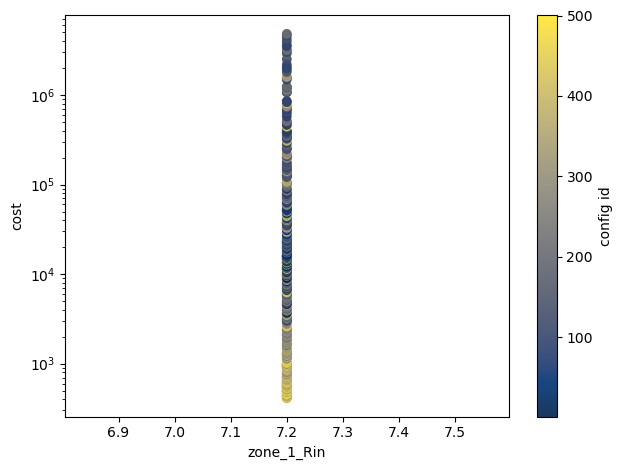

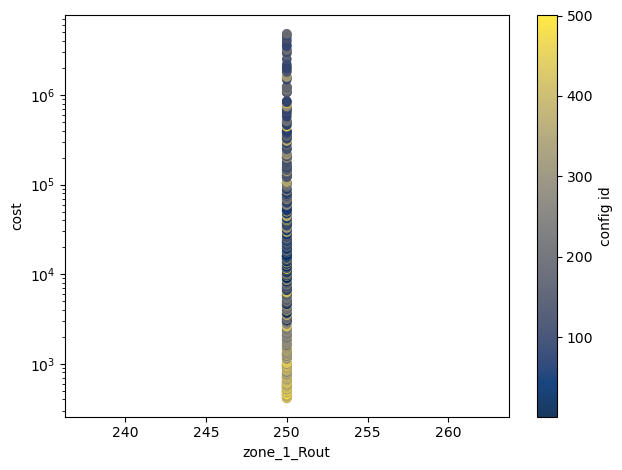

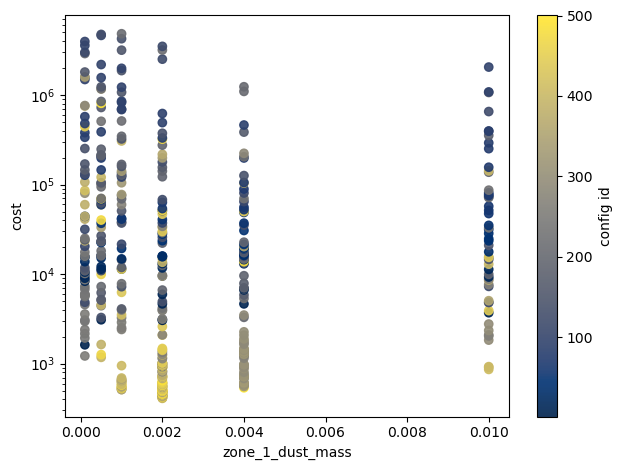

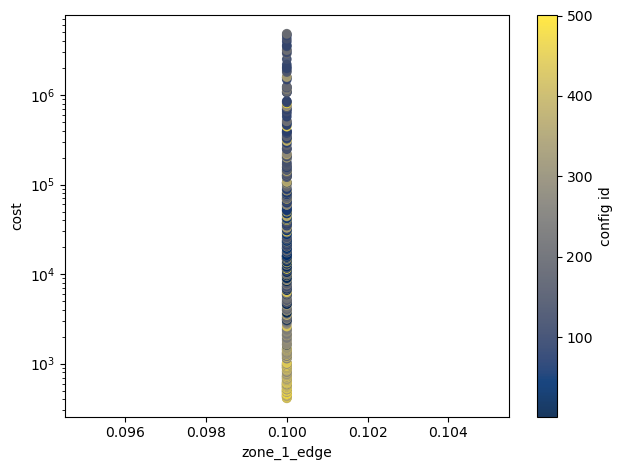

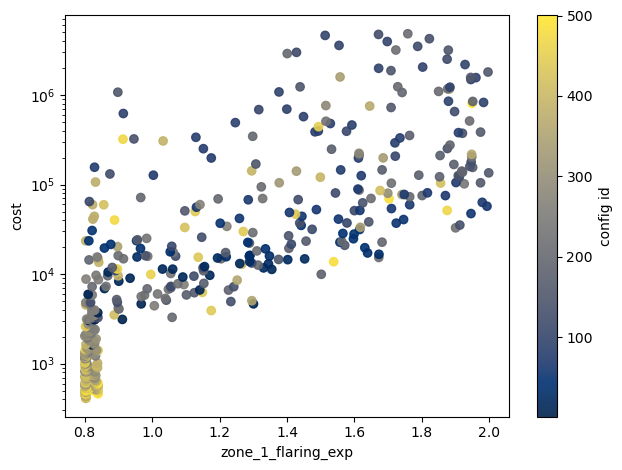

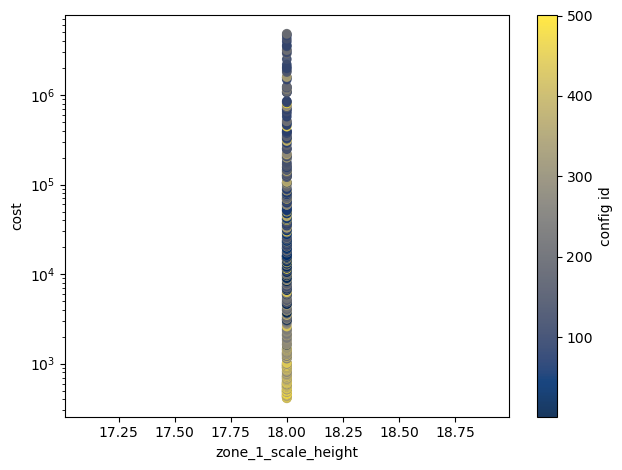

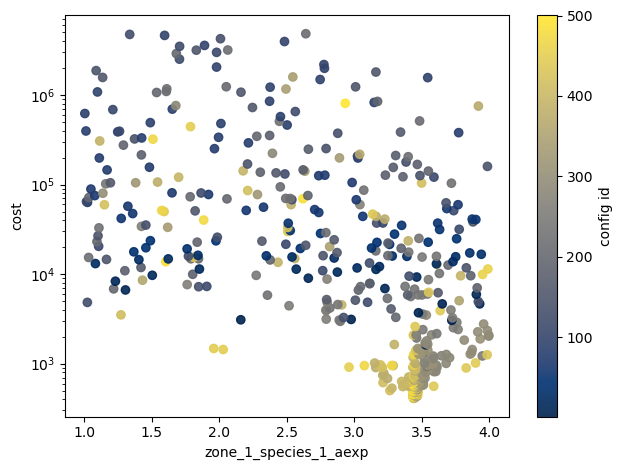

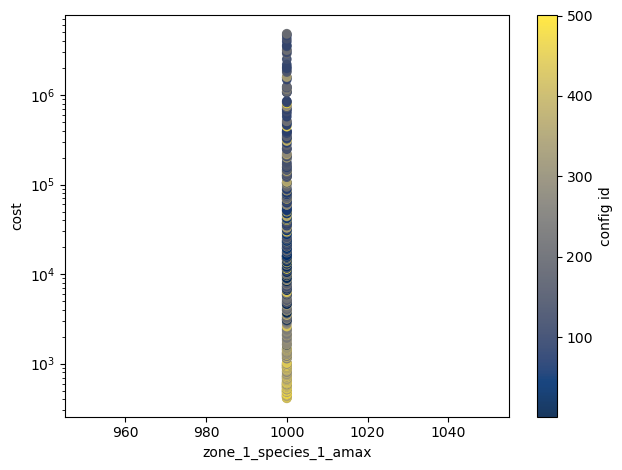

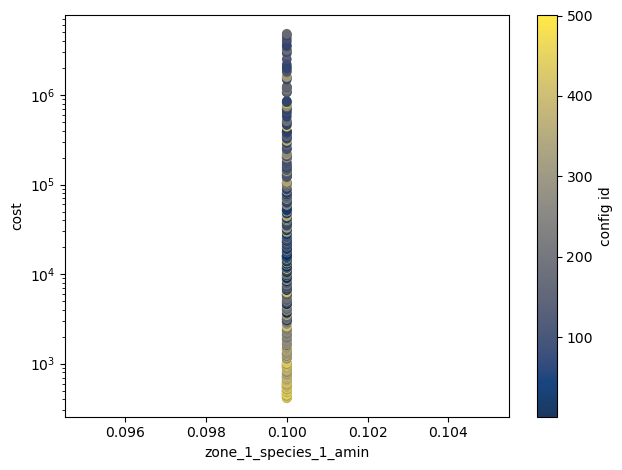

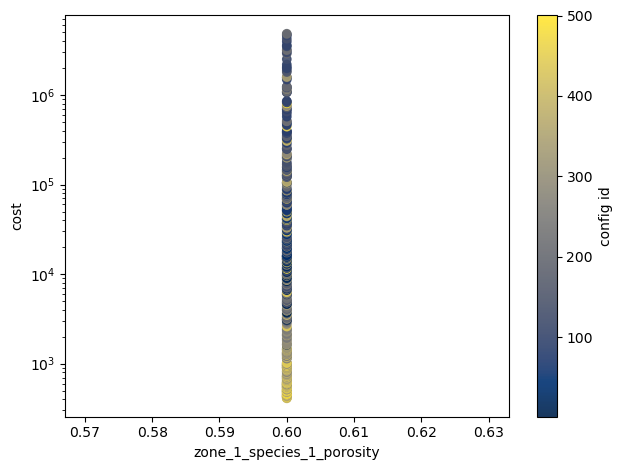

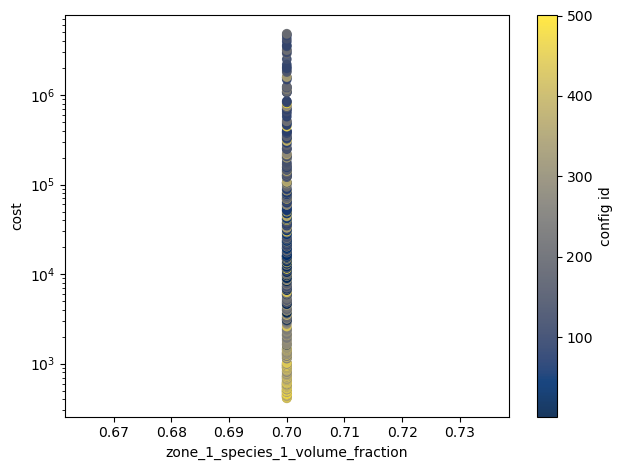

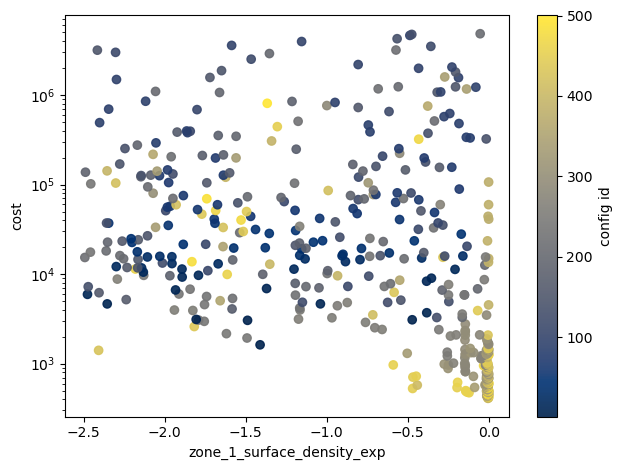

In [14]:


for p in param_cols:  # rename to your actual names
    if p in df.columns:
        plt.figure()
        sc=plt.scatter(successful_trials[p], successful_trials["cost"], c=successful_trials["config_id"], cmap='cividis', alpha=0.9)
        plt.xlabel(p)
        plt.ylabel("cost")
        cbar = plt.colorbar(sc)
        cbar.set_label("config id")

        plt.yscale("log")  # often helpful
        plt.tight_layout()
        plt.savefig(results_dir +f"scatter_{p}.png", dpi=150)
        plt.show()
        plt.close()


### Slice by budget (does the story change with fidelity?)

In [43]:
successful_trials.groupby("budget")["cost"].describe()#.to_csv(results_dir / "cost_by_budget.csv")


,count,mean,std,min,25%,50%,75%,max
budget,,,,,,,,
1.1,999.0,89261.66574,407968.417378,365.574816,447.545632,735.025718,13961.771946,4.855711e+06


### Parameter importance (fast, practical)

In [44]:
def binned_medians(successful_trials, param, bins=2):
    s = successful_trials[[param, "cost"]].dropna()
    s["bin"] = pd.qcut(s[param], q=bins, duplicates="drop")
    return s.groupby("bin", observed=True)["cost"].median().sort_values()

for p in ["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]:
    if p in successful_trials.columns:
        bm = binned_medians(successful_trials[successful_trials["budget"] == successful_trials["budget"].max()], p)
        print(f"Binned medians for {p}:")
        print(bm)
        #bm.to_csv(results_dir / f"binned_median_{p}.csv")


Binned medians for zone_1_Rc:
bin
(140.133, 199.939]     698.061473
(20.313, 140.133]     1157.352829
Name: cost, dtype: float64
Binned medians for zone_1_flaring_exp:
bin
(0.799, 0.813]      467.691363
(0.813, 1.999]    13234.523556
Name: cost, dtype: float64
Binned medians for zone_1_dust_mass:
bin
(-0.0009, 0.001]      521.314157
(0.001, 0.01]       11378.809300
Name: cost, dtype: float64
Binned medians for zone_1_species_1_porosity:
Series([], Name: cost, dtype: float64)


### Clustering of “good” solutions (degeneracies)

In [45]:

percent_of_successful = len(successful_trials)*0.1

good = successful_trials[successful_trials["budget"] == successful_trials["budget"].max()].nsmallest(int(percent_of_successful), "cost")
good.describe()#.to_csv(results_dir / "good5_summary.csv")

,alpha_viscosity,distance_pc,inclination,zone_1_Rc,zone_1_Rin,zone_1_Rout,zone_1_Rref,zone_1_dust_mass,zone_1_edge,zone_1_flaring_exp,...,zone_1_species_1_amax,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time
count,9.900000e+01,99.0,99.000000,99.000000,9.900000e+01,99.0,99.0,9.900000e+01,9.900000e+01,99.000000,...,99.0,9.900000e+01,9.900000e+01,9.900000e+01,99.000000,99.000000,9.900000e+01,9.900000e+01,99.000000,99.000000
mean,1.000000e-01,1220.0,15.022719,128.997075,7.200000e+00,250.0,100.0,1.000000e-03,1.000000e-01,0.803852,...,1000.0,1.000000e-01,6.000000e-01,7.000000e-01,-0.047913,850.636364,2.093491e+09,1.100000e+00,388.731383,252.240799
std,1.952778e-16,0.0,0.012773,9.918531,6.248889e-15,0.0,0.0,6.538319e-19,1.952778e-16,0.004007,...,0.0,1.952778e-16,1.004286e-15,1.339048e-15,0.037881,109.600709,0.000000e+00,2.008571e-15,8.153792,17.080712
min,1.000000e-01,1220.0,15.001479,105.715250,7.200000e+00,250.0,100.0,1.000000e-03,1.000000e-01,0.800161,...,1000.0,1.000000e-01,6.000000e-01,7.000000e-01,-0.127675,564.000000,2.093491e+09,1.100000e+00,365.574816,145.663198
25%,1.000000e-01,1220.0,15.015502,119.612540,7.200000e+00,250.0,100.0,1.000000e-03,1.000000e-01,0.801706,...,1000.0,1.000000e-01,6.000000e-01,7.000000e-01,-0.074017,779.500000,2.093491e+09,1.100000e+00,383.894690,243.799837
50%,1.000000e-01,1220.0,15.020872,132.674809,7.200000e+00,250.0,100.0,1.000000e-03,1.000000e-01,0.802461,...,1000.0,1.000000e-01,6.000000e-01,7.000000e-01,-0.052903,871.000000,2.093491e+09,1.100000e+00,389.623674,252.347707
75%,1.000000e-01,1220.0,15.022290,133.644431,7.200000e+00,250.0,100.0,1.000000e-03,1.000000e-01,0.803902,...,1000.0,1.000000e-01,6.000000e-01,7.000000e-01,-0.009018,943.000000,2.093491e+09,1.100000e+00,394.888381,260.475678
max,1.000000e-01,1220.0,15.060042,150.689400,7.200000e+00,250.0,100.0,1.000000e-03,1.000000e-01,0.818098,...,1000.0,1.000000e-01,6.000000e-01,7.000000e-01,-0.000506,1000.000000,2.093491e+09,1.100000e+00,401.147595,310.456246


### Plot

In [46]:
curve = successful_trials.groupby(["config_id", "budget"])["cost"].min().reset_index()
curve#.to_csv(results_dir / "learning_curves.csv", index=False)


,config_id,budget,cost
0,1,1.1,53523.174169
1,2,1.1,58836.203012
2,3,1.1,22117.008832
3,4,1.1,2198.208136
4,5,1.1,40209.060963
...,...,...,...
994,996,1.1,386.498353
995,997,1.1,398.470380
996,998,1.1,381.844372
997,999,1.1,408.449879


## For the cornerplot


SMAC does not give a true posterior.
This corner plot represents a high-likelihood region sampled by Bayesian optimisation, not an MCMC posterior.
So... distribution of high-performing models:

In [47]:
# Restrict to highest fidelity
df_max = successful_trials[successful_trials["budget"] == successful_trials["budget"].max()].copy()

# Drop failed / NaN
df_max = df_max.dropna(subset=["cost"])

# Optional: keep only the best 30% of trials
q = 0.9
cost_cut = df_max["cost"].quantile(q)
df_sel = df_max[df_max["cost"] <= cost_cut]


In [48]:
exclude = {"config_id", "seed", "budget", "cost", "time", "status", 
           'distance_pc', "zone_1_Rref"}

param_cols = [c for c in df_sel.columns if c not in exclude]
param_cols


['alpha_viscosity',
 'inclination',
 'zone_1_Rc',
 'zone_1_Rin',
 'zone_1_Rout',
 'zone_1_dust_mass',
 'zone_1_edge',
 'zone_1_flaring_exp',
 'zone_1_scale_height',
 'zone_1_species_1_aexp',
 'zone_1_species_1_amax',
 'zone_1_species_1_amin',
 'zone_1_species_1_porosity',
 'zone_1_species_1_volume_fraction',
 'zone_1_surface_density_exp']

ValueError: It looks like the parameter(s) in column(s) 3, 4, 6, 8, 10, 11, 12, 13 have no dynamic range. Please provide a `range` argument.

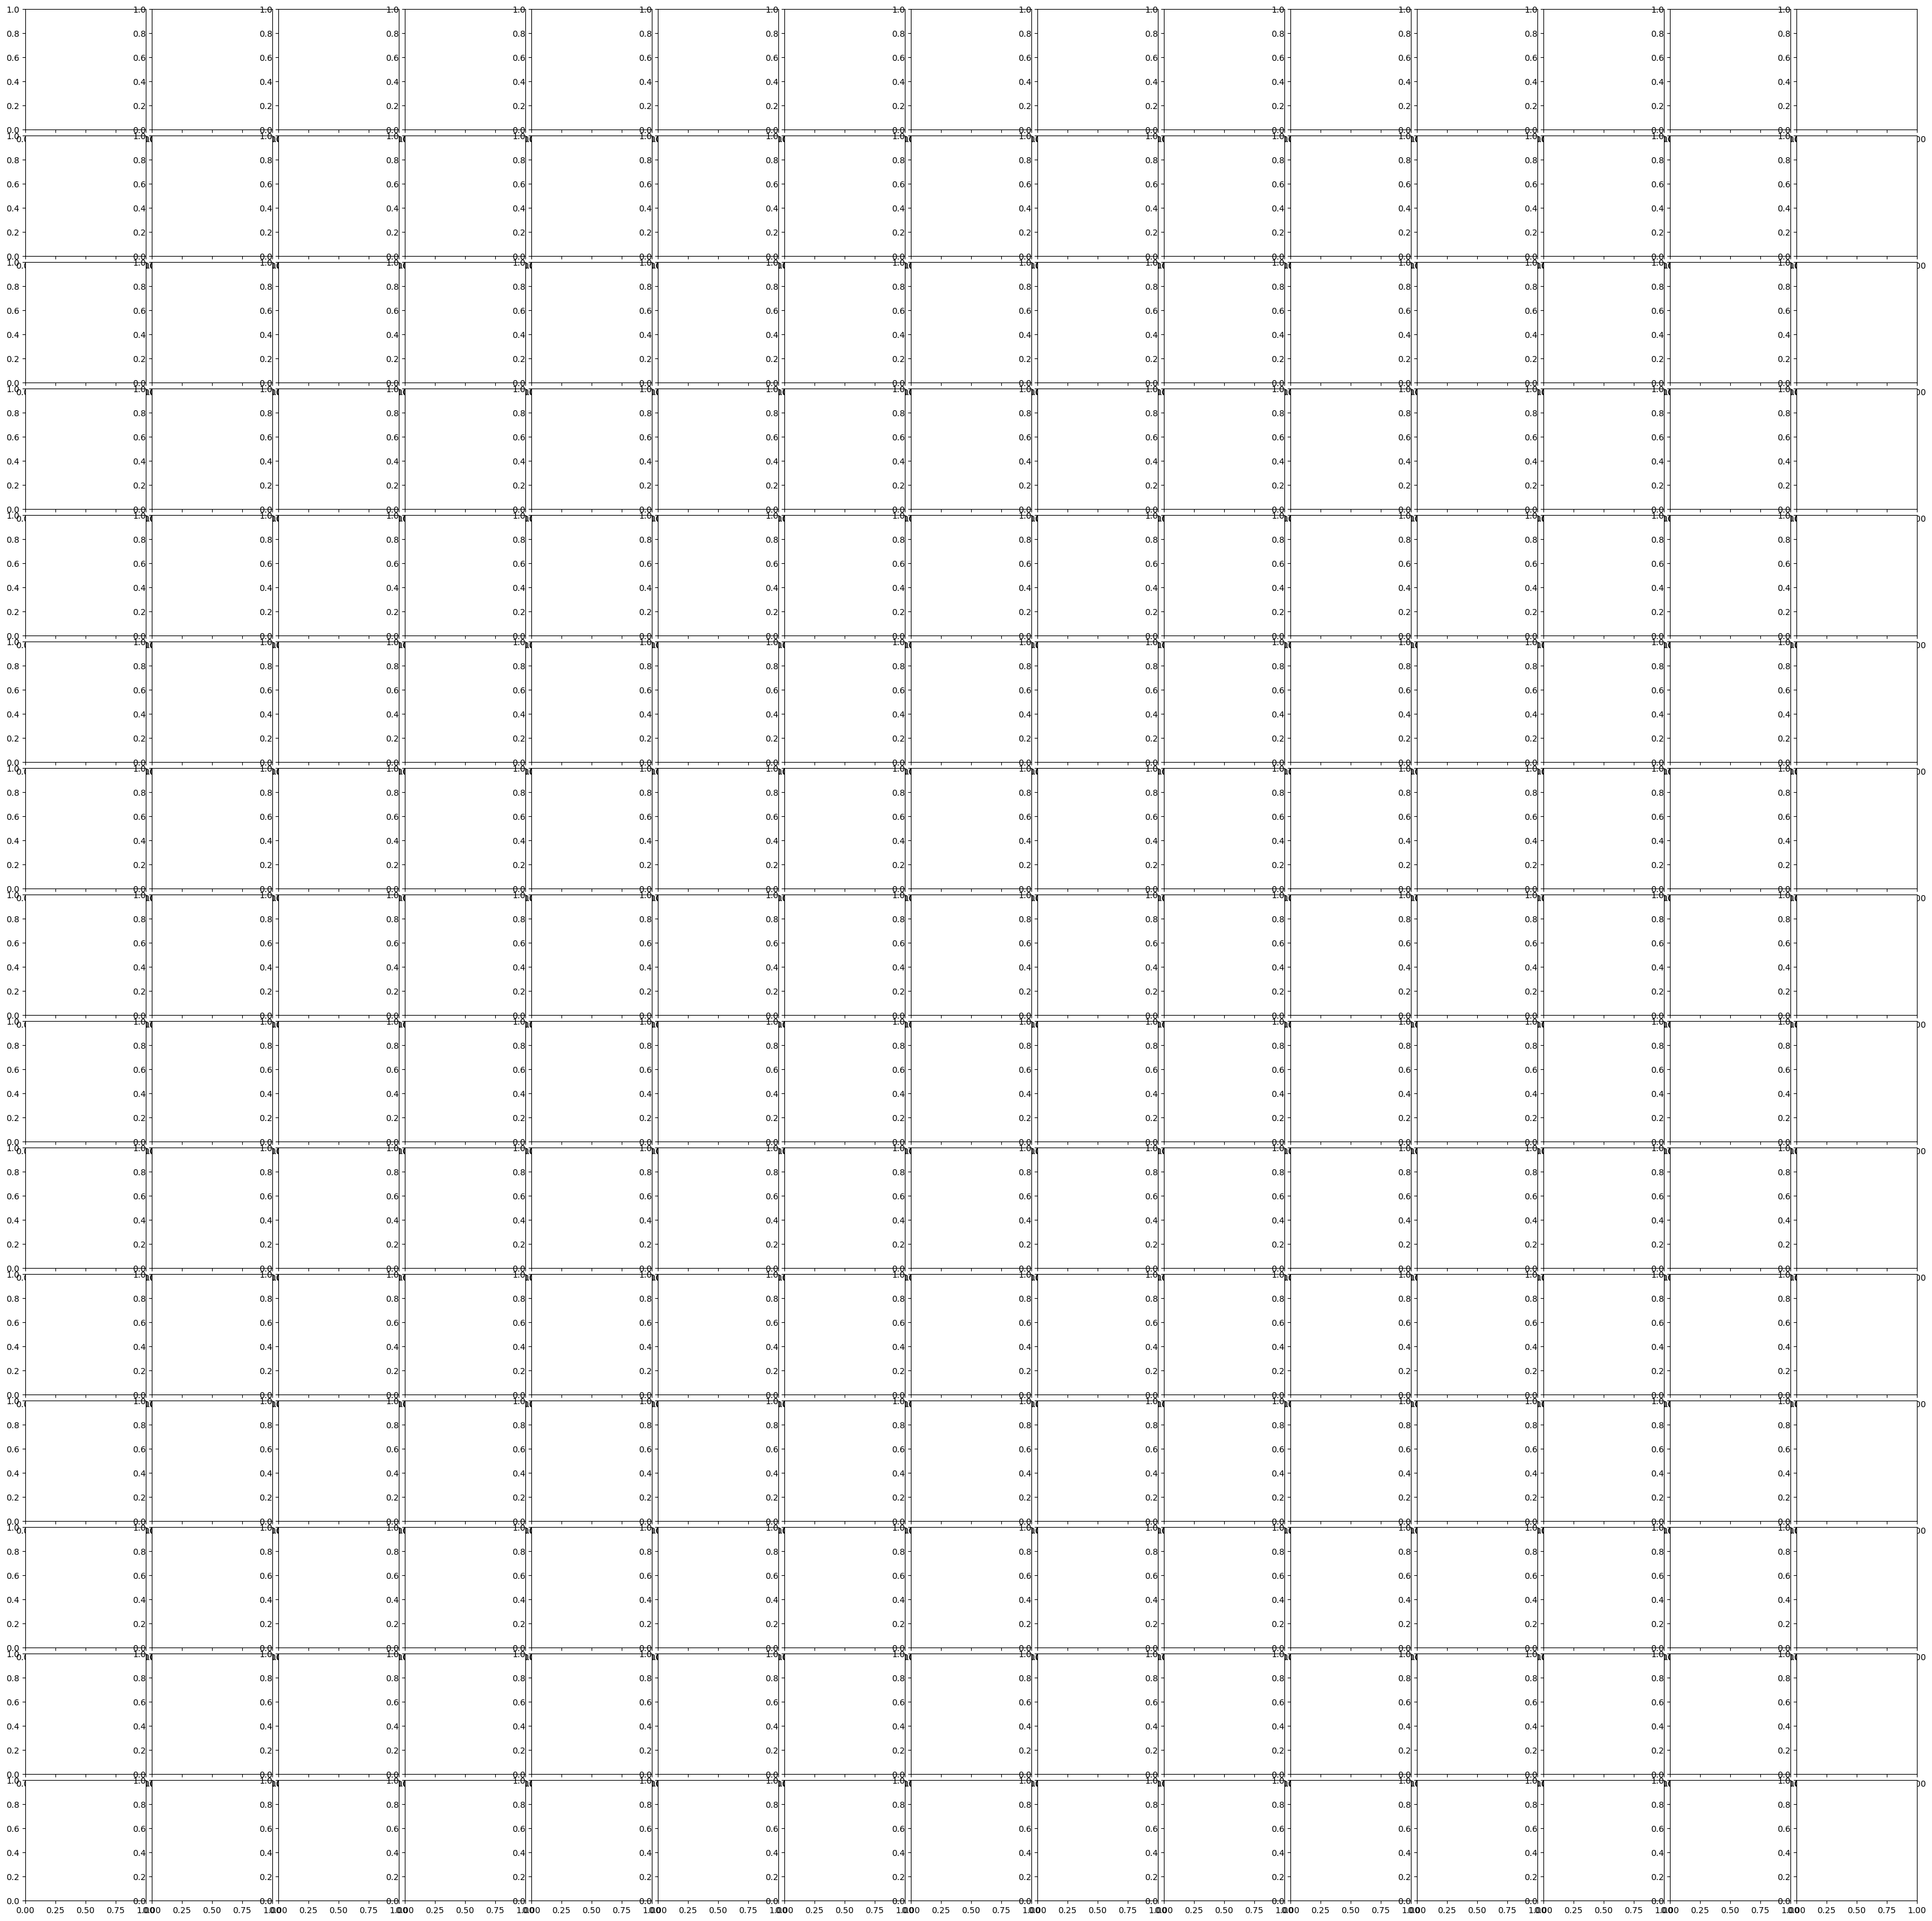

In [49]:
data = df_sel[param_cols].values

fig = corner.corner(
    data,
    labels=param_cols,
    truths=None,              # optional: known reference values
    # quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
)

fig.savefig(results_dir +"corner_all_params.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

weights = 1.0 / df_sel["cost"].values

fig = corner.corner(
    data,
    labels=param_cols,
    weights=weights,
    show_titles=True,
)
fig.savefig(results_dir +"corner_all_params_weighted.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)



In [ ]:
#just one function to do it
#WORKS

def make_corner_plot(
    df,
    params,
    *,
    budget=None,
    best_quantile=0.3,
    title=None,
    outfile="corner.png",
):

    d = df.copy()
    if budget is not None:
        d = d[d["budget"] == budget]

    d = d.dropna(subset=["cost"])
    cost_cut = d["cost"].quantile(best_quantile)
    d = d[d["cost"] <= cost_cut]
    if len(d) == 0:
        print("No data to plot after filtering by budget and cost quantile.")
        return
    params_corner = []
    for p in params:
        if p not in d.columns:
            raise ValueError(f"Parameter '{p}' not found in DataFrame columns.")
        if d[p].unique().size >= 2:
            params_corner.append(p)
        else:
            print(f"Parameter '{p}' has less than 2 unique values in the filtered DataFrame.")


    if len(params_corner) == 0:
        print("No valid parameters to plot after filtering.")
        return
    data = d[params_corner].values

    fig = corner.corner(
        data,
        labels=params_corner,
        quantiles=[0.16, 0.5, 0.84],
        weights=1.0 / d["cost"].values,
        show_titles=True,
        wrap_title_quantiles=True,
        title_fmt=".3g"  
    )
    plt.suptitle(title, fontsize=14, y=1.01)
    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)




        zone_1_Rc  zone_1_flaring_exp  zone_1_dust_mass  \
count  899.000000          899.000000        899.000000   
mean   104.678795            1.243142          0.001515   
std     35.621190            0.213209          0.002419   
min     20.225823            0.803349          0.000100   
25%     83.832420            1.173716          0.000500   
50%    106.680720            1.192189          0.000500   
75%    126.553341            1.256595          0.001000   
max    199.432081            1.994575          0.010000   

       zone_1_species_1_porosity  
count               8.990000e+02  
mean                6.000000e-01  
std                 9.997569e-15  
min                 6.000000e-01  
25%                 6.000000e-01  
50%                 6.000000e-01  
75%                 6.000000e-01  
max                 6.000000e-01  
Parameter 'zone_1_species_1_porosity' has less than 2 unique values in the filtered DataFrame.


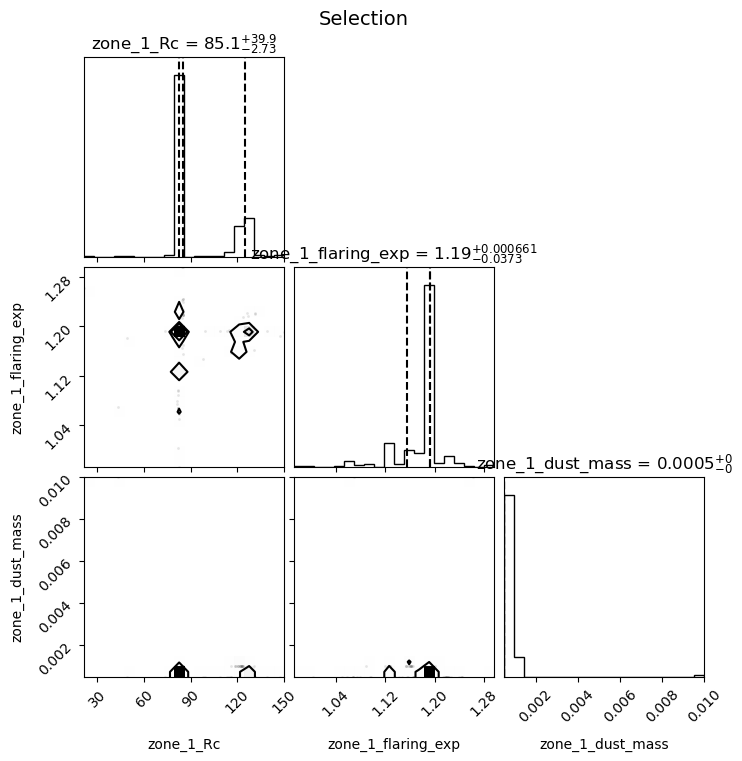

In [ ]:
param_cols=["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]
print(df_sel[param_cols].describe())

make_corner_plot(
    df_sel,
    params=param_cols,
    budget=df_sel["budget"].max(),
    outfile=results_dir+ "corner_best.png",
    title="Selection"
)


## setting up subgroups of parameters for corner plots

Parameters for 'Grid setup parameters': []
[]
Parameters for 'Disk orientation parameters': ['distance_pc']
Parameter 'distance_pc' has less than 2 unique values in the filtered DataFrame.
[]
Parameters for 'Disk geometry parameters': ['zone_1_Rc', 'zone_1_Rin', 'zone_1_Rout', 'zone_1_Rref', 'zone_1_edge', 'zone_1_flaring_exp', 'zone_1_scale_height', 'zone_1_surface_density_exp']
Parameter 'zone_1_Rin' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_Rout' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_Rref' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_edge' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_scale_height' has less than 2 unique values in the filtered DataFrame.
['zone_1_Rc', 'zone_1_flaring_exp', 'zone_1_surface_density_exp']
Corner plot for Disk geometry parameters:


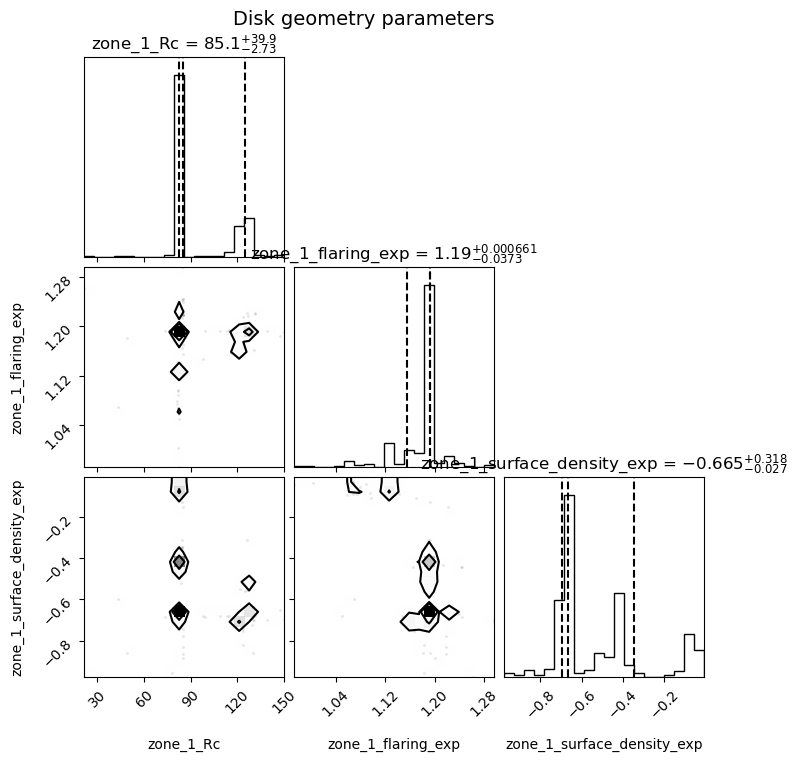

Parameters for 'Dust distribution parameters': ['alpha_viscosity', 'zone_1_dust_mass']
['alpha_viscosity', 'zone_1_dust_mass']
Corner plot for Dust distribution parameters:


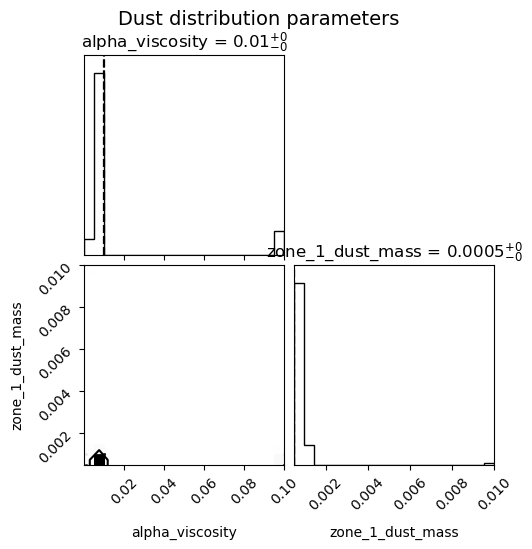

Parameters for 'Dust grain parameters': ['zone_1_species_1_aexp', 'zone_1_species_1_amax', 'zone_1_species_1_amin', 'zone_1_species_1_porosity', 'zone_1_species_1_volume_fraction']
Parameter 'zone_1_species_1_amax' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_species_1_amin' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_species_1_porosity' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_species_1_volume_fraction' has less than 2 unique values in the filtered DataFrame.
['zone_1_species_1_aexp']
Parameters for 'Star parameters': []
[]


In [ ]:
#all parameters

grid_setup_parameters=["grid_geometry", "n_rad", "nz", "n_az", "n_rad_in", "grid_nx", "grid_ny", "grid_size"]
disk_orientation_parameters=["imin", "imax", "n_incl", "centered", "az_min", "az_max", "distance_pc", "disk_pa"]
disk_geometry_parameters=["zone_1_scale_height", "zone_1_Rref", "zone_1_vertical_profile_exponent", "zone_1_Rin", "zone_1_edge", "zone_1_Rout", "zone_1_Rc", "zone_1_flaring_exp", "zone_1_surface_density_exp", "zone_1_-gamma_exp"]
dust_distribution_parameters=["dust_settling", "exp_strat", "a_strat", "dust_radial_migration", "sublimate_dust", "hydrostatic_equilibrium", "viscous_heating", "alpha_viscosity",
                          "zone_1_dust_mass", "zone_1_gas_to_dust"]
dust_grain_parameters=["zone_1_species_1_grain_type", "zone_1_species_1_N_components", "zone_1_species_1_mixing_rule", "zone_1_species_1_porosity", "zone_1_species_1_mass_fraction", "zone_1_species_1_Vmax", "zone_1_species_1_optical_indices_file", "zone_1_species_1_volume_fraction", "zone_1_species_1_heating_method",
                       "zone_1_species_1_amin", "zone_1_species_1_amax", "zone_1_species_1_aexp", "zone_1_species_1_n_grains"]
star_parameters=["star_1_Temp", "star_1_R", "star_1_M", "star_1_x", "star_1_y", "star_1_z", "star_1_autometic_spectrum", "star_1_spectrum_file", "star_1_fUV", "star_1_slope_fUV"]  


titles={"Grid setup parameters": grid_setup_parameters,
        "Disk orientation parameters": disk_orientation_parameters,
        "Disk geometry parameters": disk_geometry_parameters,
        "Dust distribution parameters": dust_distribution_parameters,
        "Dust grain parameters": dust_grain_parameters,
        "Star parameters": star_parameters}

for title in titles.keys():
    param_subset = titles[title]
    param_cols_set = [c for c in df_sel.columns if c in param_subset]
    param_cols_corner = []  # Initialize a list to keep track of parameters with less than 2 unique values
    print(f"Parameters for '{title}': {param_cols_set}")
    for p in param_cols_set:
        if df_sel[p].unique().size >= 2:
            param_cols_corner.append(p) 
        else:
            print(f"Parameter '{p}' has less than 2 unique values in the filtered DataFrame.")

    print(param_cols_corner)

    if len(param_cols_corner)>1:
        print(f"Corner plot for {title}:")
        
        #print(df_sel[param_cols_set].describe())

        make_corner_plot(
            df_sel,
            params=param_cols_corner,
            budget=df_sel["budget"].max(),
            title=title,
            outfile=results_dir+ f"corner_{title}_best.png"
        )

